<a href="https://colab.research.google.com/github/BandanaSingha24/Integrated_Multiomic_Survival_Model/blob/main/Mutation_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as panda

df=panda.read_csv("/content/processed_mutation_feature_engineered_data.csv")
print(df.head())

   Unnamed: 0  ACVRL1  AFF2  AGMO  AGTR2  AHNAK  AHNAK2  AKAP9  AKT1  AKT2  \
0           0       0     0     0      0      0       0      0     0     0   
1           1       0     0     0      0      0       0      0     0     0   
2           2       0     0     0      0      0       0      0     0     0   
3           3       0     0     0      0      0       0      0     0     0   
4           4       0     0     0      0      0       0      0     0     0   

   ...  THADA  THSD7A  TP53  TTYH1  UBR5  USH2A  USP28  USP9X  UTRN  ZFP36L1  
0  ...      0       0     1      0     0      0      0      0     0        0  
1  ...      0       0     0      0     0      0      0      0     0        0  
2  ...      0       0     0      0     0      0      0      0     0        0  
3  ...      0       0     1      0     0      0      0      0     0        0  
4  ...      0       0     1      0     0      0      0      0     0        0  

[5 rows x 174 columns]


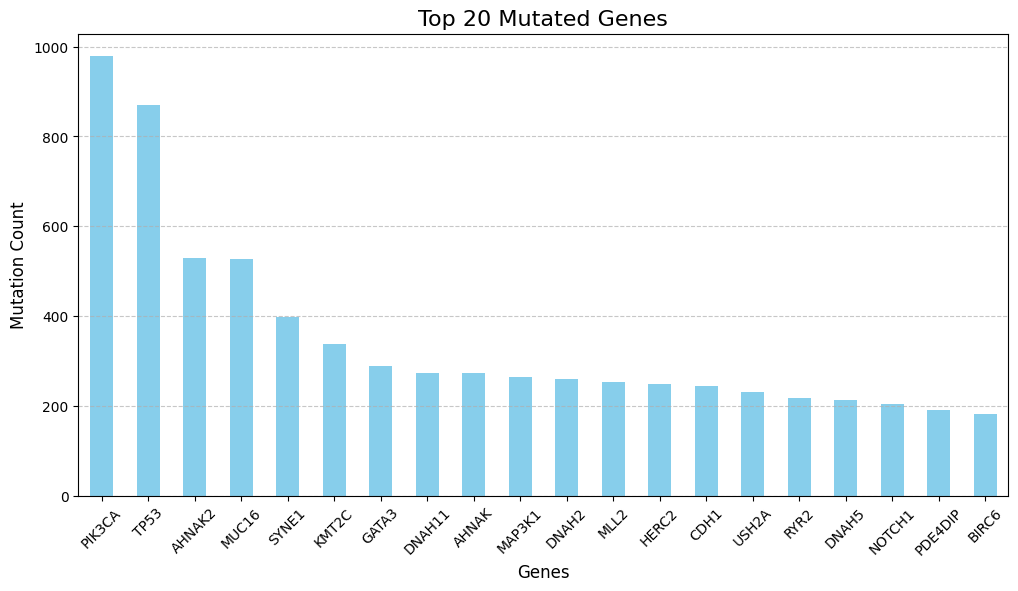

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Top Mutated Gene bar plot

# 1. Identify Top Mutated Gene
# Dropping the index column for calculation
mutation_data = df.drop(columns=['Unnamed: 0'])

# 2. Calculate sum of mutations per gene
top_genes = mutation_data.sum().sort_values(ascending=False)

# 3. Visualization: Barplot of Top 20 Mutated Genes
plt.figure(figsize=(12, 6))
top_genes.head(20).plot(kind='bar', color='skyblue')

# Setting labels and title
plt.title('Top 20 Mutated Genes', fontsize=16)
plt.xlabel('Genes', fontsize=12)
plt.ylabel('Mutation Count', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


In [6]:
 #Check the names of all columns in your dataframe
print(df.columns.tolist())

['Unnamed: 0', 'ACVRL1', 'AFF2', 'AGMO', 'AGTR2', 'AHNAK', 'AHNAK2', 'AKAP9', 'AKT1', 'AKT2', 'ALK', 'APC', 'ARID1A', 'ARID1B', 'ARID2', 'ARID5B', 'ASXL1', 'ASXL2', 'ATR', 'BAP1', 'BCAS3', 'BIRC6', 'BRAF', 'BRCA1', 'BRCA2', 'BRIP1', 'CACNA2D3', 'CASP8', 'CBFB', 'CCND3', 'CDH1', 'CDKN1B', 'CDKN2A', 'CHD1', 'CHEK2', 'CLK3', 'CLRN2', 'COL12A1', 'COL22A1', 'COL6A3', 'CTCF', 'CTNNA1', 'CTNNA3', 'DCAF4L2', 'DNAH11', 'DNAH2', 'DNAH5', 'DTWD2', 'EGFR', 'EP300', 'ERBB2', 'ERBB3', 'ERBB4', 'FAM20C', 'FANCA', 'FANCD2', 'FBXW7', 'FLT3', 'FOXO1', 'FOXO3', 'FOXP1', 'FRMD3', 'GATA3', 'GH1', 'GLDC', 'GPR124', 'GPR32', 'GPS2', 'HDAC9', 'HERC2', 'HIST1H2BC', 'HRAS', 'JAK1', 'KDM3A', 'KDM6A', 'KLRG1', 'KMT2C', 'KRAS', 'L1CAM', 'LAMA2', 'LAMB3', 'LARGE', 'LDLRAP1', 'LIFR', 'LIPI', 'MAGEA8', 'MAP2K4', 'MAP3K1', 'MAP3K10', 'MAP3K13', 'MBL2', 'MEN1', 'MLL2', 'MLLT4', 'MTAP', 'MUC16', 'MYH9', 'MYO1A', 'MYO3A', 'NCOA3', 'NCOR1', 'NCOR2', 'NDFIP1', 'NEK1', 'NF1', 'NF2', 'NOTCH1', 'NPNT', 'NR2F1', 'NR3C1', 'NRAS

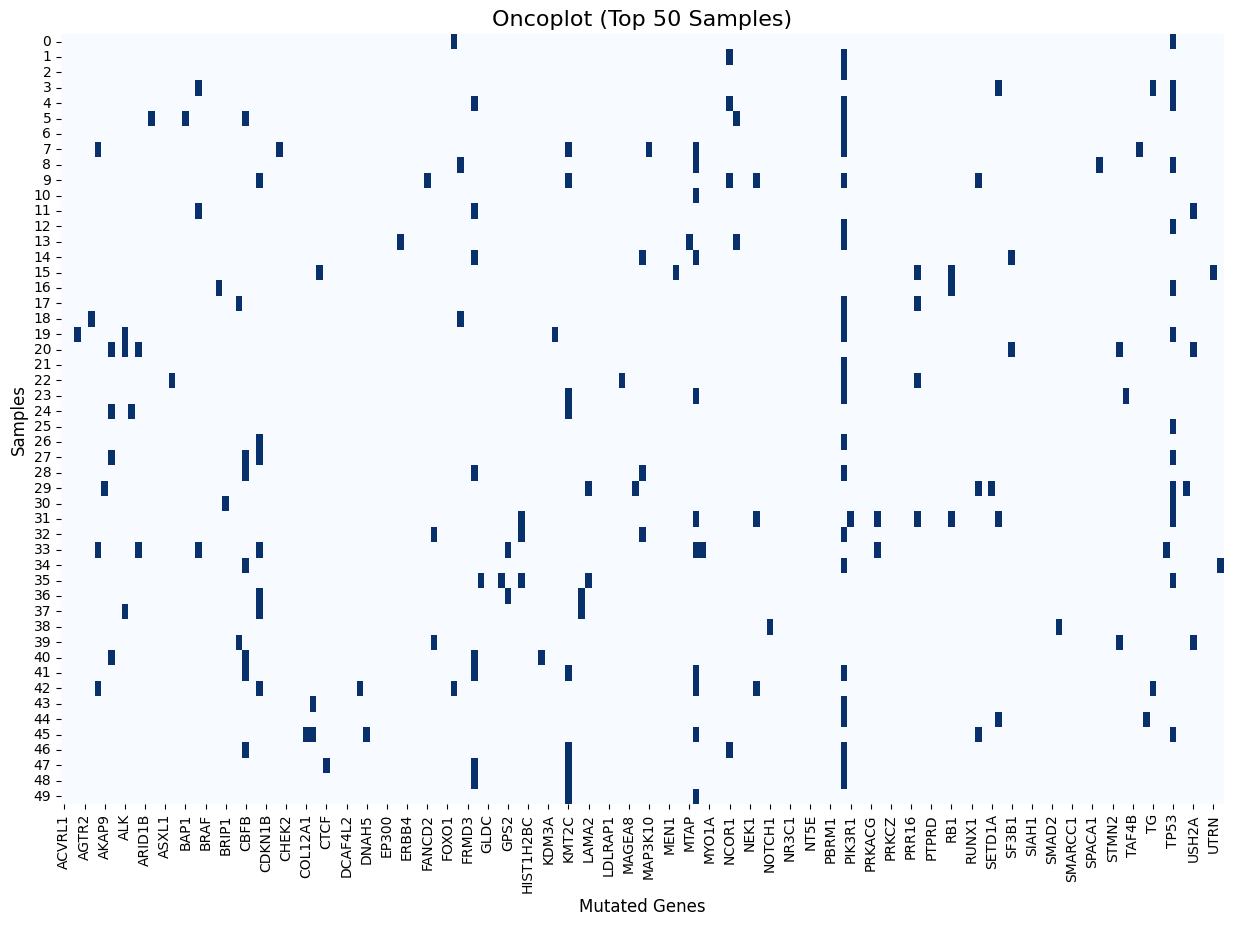

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# step 2: Setting up the Oncoplot (Heatmap of Binary Matrix)
plt.figure(figsize=(15, 10))
sns.heatmap(df.drop(columns=['Unnamed: 0']).head(50), cmap='Blues', cbar=False)

# Title and label
plt.title('Oncoplot (Top 50 Samples)', fontsize=16)
plt.xlabel('Mutated Genes', fontsize=12)
plt.ylabel('Samples', fontsize=12)

# Display
plt.show()


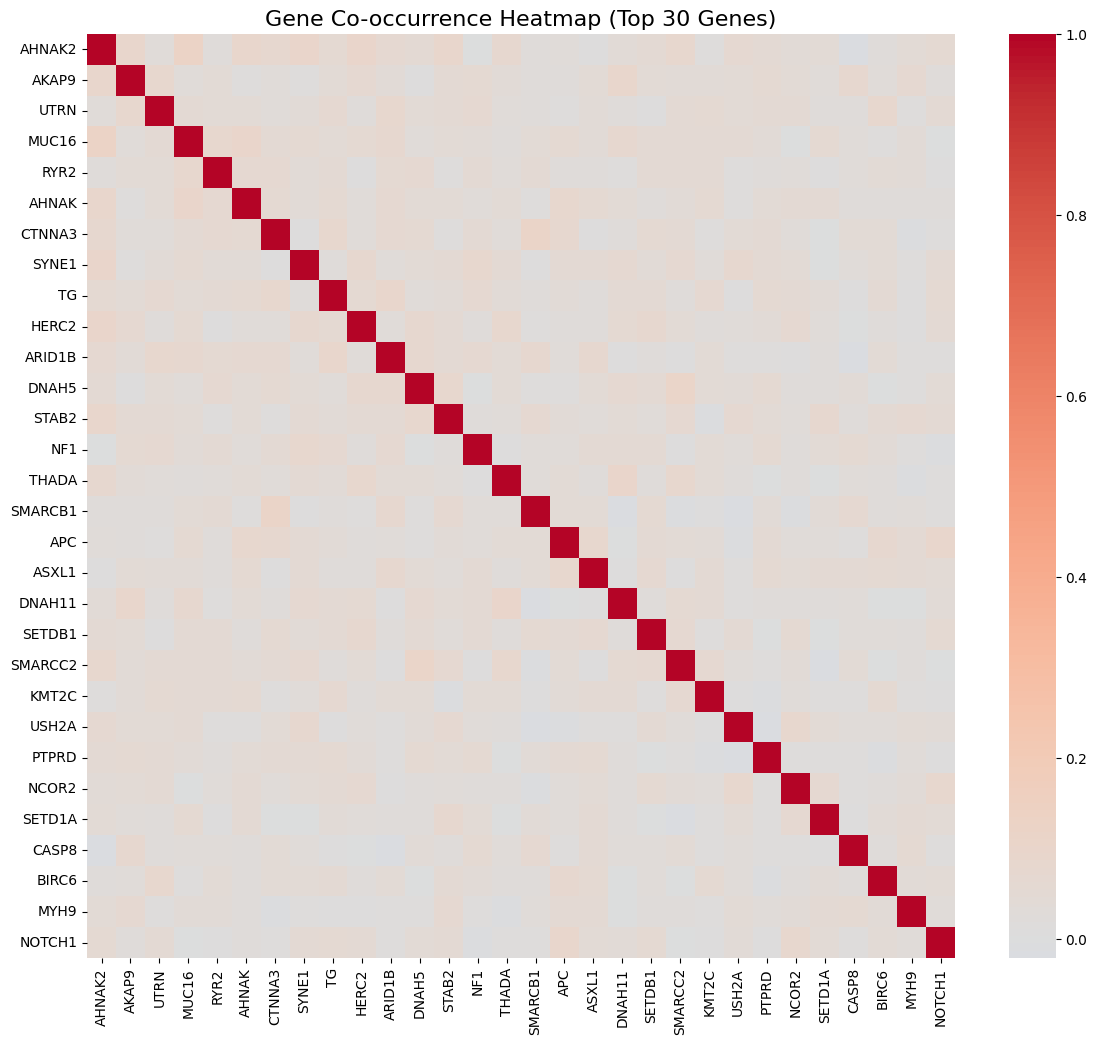

In [8]:
# Step 3: Gene Co-occurrence Analysis (Correlation Heatmap)


# 1.Creating the correlation matrix for mutation data
corr_matrix = df.drop(columns=['Unnamed: 0']).corr()

# 2 Selecting top 30 genes for a clear heatmap
top_30_genes = corr_matrix.sum().sort_values(ascending=False).head(30).index
corr_subset = corr_matrix.loc[top_30_genes, top_30_genes]

# Creating the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_subset, cmap='coolwarm', center=0, annot=False)

# Adding labels and title
plt.title('Gene Co-occurrence Heatmap (Top 30 Genes)', fontsize=16)
plt.show()


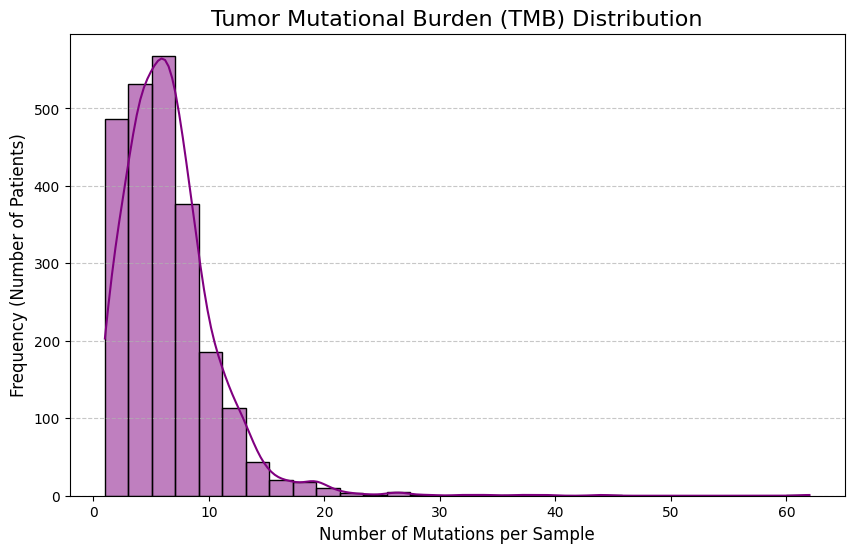

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 4: Calculate and Visualize Tumor Mutational Burden (TMB)

# 1. Calculating total mutations per sample (sum of genes)
df['TMB'] = df.drop(columns=['Unnamed: 0']).sum(axis=1)

# 2.Plotting the distribution of TMB
plt.figure(figsize=(10, 6))
sns.histplot(df['TMB'], bins=30, kde=True, color='purple')
# Adding title and labels
plt.title('Tumor Mutational Burden (TMB) Distribution', fontsize=16)
plt.xlabel('Number of Mutations per Sample', fontsize=12)
plt.ylabel('Frequency (Number of Patients)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Displaying the plot
plt.show()



In [11]:
df_mut = pd.read_csv('data_mutations.txt', sep='\t', comment='#')

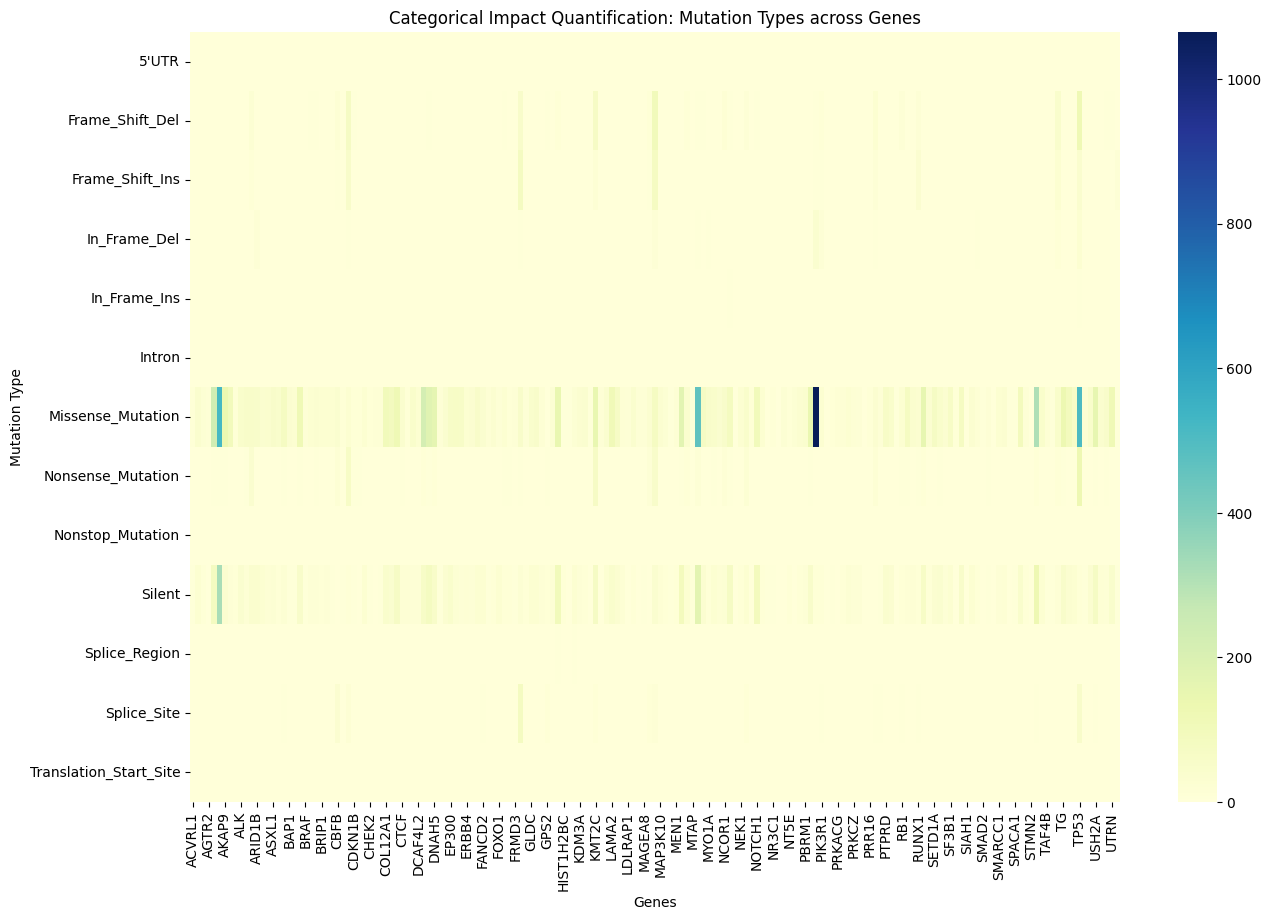

In [12]:
# ========================================================
# STEP 5: Categorical Impact Quantification
# ========================================================

# 1. Analyzing the impact of mutation types across different genes
# to identify mutation hotspots.
# म्यूटेशन के प्रकारों का विभिन्न जीन्स पर प्रभाव विश्लेषित करना
# ताकि म्यूटेशन हॉटस्पॉट्स की पहचान की जा सके।
mutation_impact = df_mut.groupby('Variant_Classification')['Hugo_Symbol'].value_counts().unstack().fillna(0)

# 2. Visualizing the mutation distribution using a heatmap to understand
# functional impact on genomic stability.
# जीनोमिक स्थिरता पर कार्यात्मक प्रभाव को समझने के लिए
# हीटमैप का उपयोग करके म्यूटेशन वितरण को विज़ुअलाइज़ करना।
plt.figure(figsize=(15, 10))
sns.heatmap(mutation_impact, cmap='YlGnBu', annot=False)

# 3. Setting titles and labels for the visualization.
# विज़ुअलाइज़ेशन के लिए टाइटल और लेबल्स सेट करना।
plt.title('Categorical Impact Quantification: Mutation Types across Genes')
plt.xlabel('Genes')
plt.ylabel('Mutation Type')
plt.show()

# 4. Final Interpretation Note:
# This heatmap quantifies how different mutation types cluster in driver genes,
# highlighting potential clinical targets for further research.
# यह हीटमैप बताता है कि अलग-अलग म्यूटेशन ड्राइवर जीन्स में कैसे क्लस्टर होते हैं,
# जो आगे की रिसर्च के लिए महत्वपूर्ण नैदानिक लक्ष्य (Clinical Targets) को इंगित करता है।


In [15]:
# IDENTIFYING THE TOP MUTATED GENE (Key Finding)

# 1. Calculating the total number of mutations per gene across all samples
top_genes = df_mut['Hugo_Symbol'].value_counts()

# 2. Extracting the name of the top mutated gene.
top_gene_name = top_genes.idxmax()
top_gene_count = top_genes.max()

# 3. Printing the result.
print(f"The most frequently mutated gene is: {top_gene_name}")
print(f"Total mutations in this gene: {top_gene_count}")

# 4. Professional Interpretation:
# This gene represents the primary driver in our dataset,
# making it the most critical clinical target for further analysis.

top_genes.to_csv("top_mutated_genes.csv")

The most frequently mutated gene is: PIK3CA
Total mutations in this gene: 1122


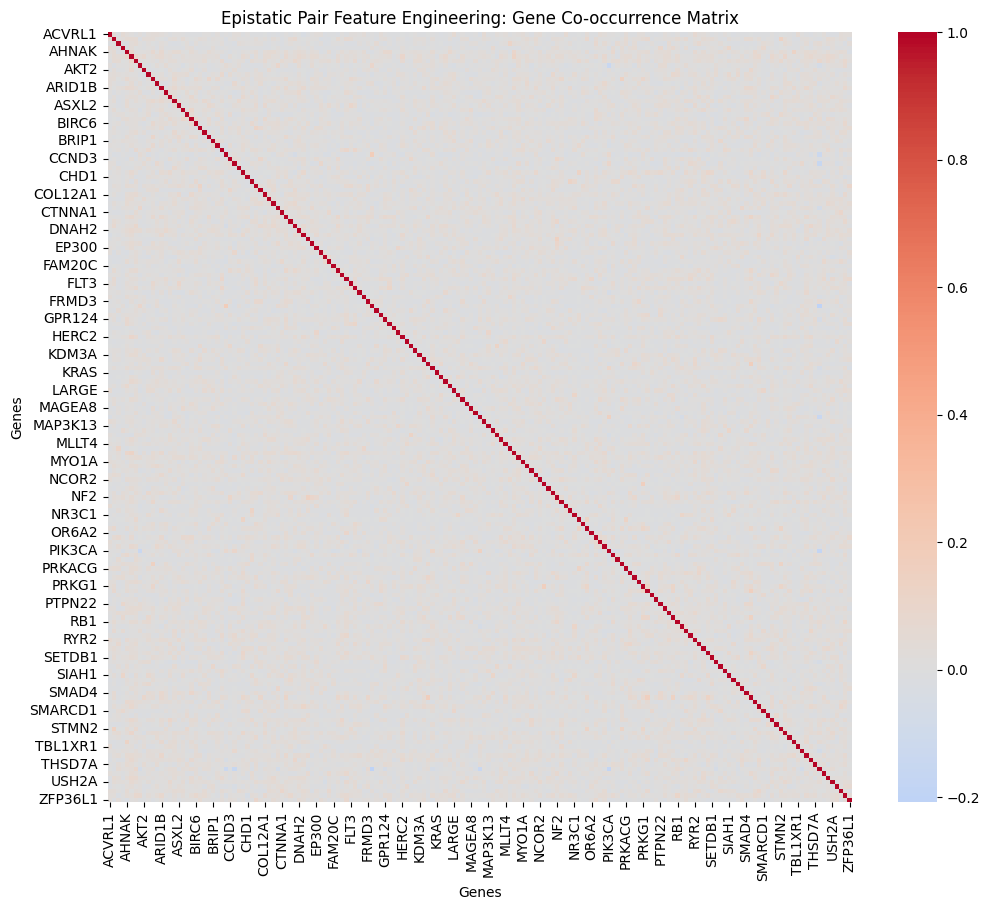

Top Epistatic (Co-occurring) Gene Pairs found:
Series([], dtype: float64)

Epistatic pairs saved successfully to 'epistatic_pairs.csv'!


In [17]:
# STEP 6: Epistatic Pair Feature Engineering

# 1. Create a binary matrix: Rows = Samples, Columns = Genes
# (1 if mutated, 0 if not). This is essential for correlation
mutation_binary = pd.crosstab(df_mut['Tumor_Sample_Barcode'], df_mut['Hugo_Symbol']).clip(upper=1)

# 2. Calculating the correlation between genes (Co-occurrence matrix).
epistatic_corr = mutation_binary.corr(method='pearson')

# 3. Visualizing the co-occurrence matrix using a heatmap.
plt.figure(figsize=(12, 10))
sns.heatmap(epistatic_corr, cmap='coolwarm', center=0, annot=False)

# 4. Adding titles and labels for professional presentation.
plt.title('Epistatic Pair Feature Engineering: Gene Co-occurrence Matrix')
plt.xlabel('Genes')
plt.ylabel('Genes')
plt.show()

# 5. Extracting highly correlated pairs for clinical research.
# (यहाँ हम उन जीन्स को देख रहे हैं जिनका 'Pearson correlation' 0.5 से ज्यादा है)
threshold = 0.5
high_corr_pairs = epistatic_corr.unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[(high_corr_pairs > threshold) & (high_corr_pairs < 1.0)]

print("Top Epistatic (Co-occurring) Gene Pairs found:")
print(high_corr_pairs.head(10))

# 6. Saving this result as a CSV for future multi-omics integration.
high_corr_pairs.to_csv('epistatic_pairs.csv')
print("\nEpistatic pairs saved successfully to 'epistatic_pairs.csv'!")

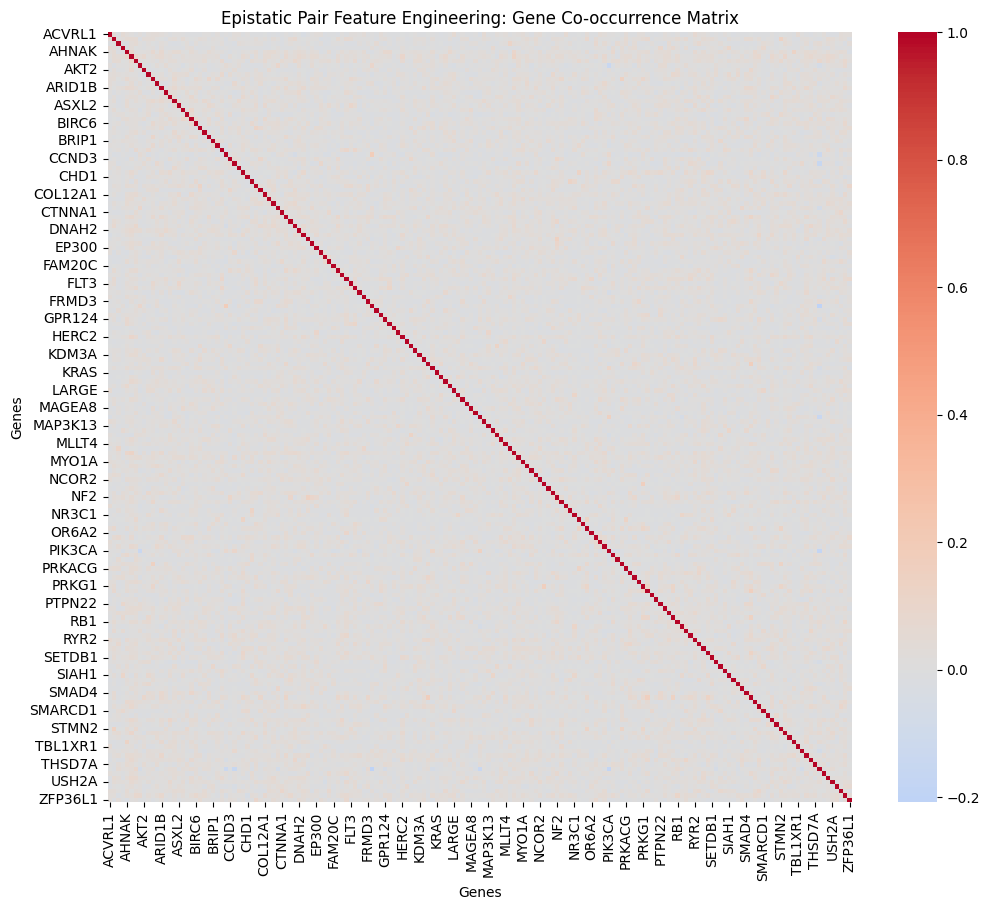

Top Epistatic (Co-occurring) Gene Pairs found (ordered by correlation):
Hugo_Symbol  Hugo_Symbol
CBFB         GATA3          0.184929
GATA3        CBFB           0.184929
SMARCB1      KLRG1          0.166956
KLRG1        SMARCB1        0.166956
PRKG1        NDFIP1         0.162174
NDFIP1       PRKG1          0.162174
SMARCB1      PRPS2          0.155872
PRPS2        SMARCB1        0.155872
PIK3CA       MAP3K1         0.146511
MAP3K1       PIK3CA         0.146511
dtype: float64

Epistatic pairs saved successfully to 'epistatic_pairs.csv'!

Epistatic pairs saved successfully to 'epistatic_pairs.csv'!


In [21]:
# STEP 6: Epistatic Pair Feature Engineering
# स्टेप 6: एपिस्टेटिक पेयर फीचर इंजीनियरिंग
# ========================================================

# 1. Create a binary matrix: Rows = Samples, Columns = Genes
# (1 if mutated, 0 if not). This is essential for correlation.
# हम एक बाइनरी मैट्रिक्स बना रहे हैं: पंक्तियाँ = सैंपल्स, कॉलम = जीन्स।
# 1 का मतलब म्यूटेशन है, 0 का मतलब नहीं है। यह कोरिलेशन के लिए जरूरी है।
mutation_binary = pd.crosstab(df_mut['Tumor_Sample_Barcode'], df_mut['Hugo_Symbol']).clip(upper=1)

# 2. Calculating the correlation between genes (Co-occurrence matrix).
# जीन्स के बीच 'co-occurrence' (सह-घटना) का कोरिलेशन निकालना।
epistatic_corr = mutation_binary.corr(method='pearson')

# 3. Visualizing the co-occurrence matrix using a heatmap.
# हीटमैप का उपयोग करके एपिस्टेटिक पेयर्स को विज़ुअलाइज़ करना।
plt.figure(figsize=(12, 10))
sns.heatmap(epistatic_corr, cmap='coolwarm', center=0, annot=False)

# 4. Adding titles and labels for professional presentation.
# विज़ुअलाइज़ेशन के लिए टाइटल और लेबल्स।
plt.title('Epistatic Pair Feature Engineering: Gene Co-occurrence Matrix')
plt.xlabel('Genes')
plt.ylabel('Genes')
plt.show()

# 5. Extracting highly correlated pairs for clinical research.
# क्लीनिकल रिसर्च के लिए सबसे ज्यादा संबंधित (correlated) पेयर्स को निकालना।
# (यहाँ हम उन जीन्स को देख रहे हैं जिनका 'Pearson correlation' 0.5 से ज्यादा है)
# Since no pairs were found above 0.2, we will now display the top 10 most correlated pairs regardless of threshold.
high_corr_pairs = epistatic_corr.unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs < 1.0] # Exclude self-correlation

print("Top Epistatic (Co-occurring) Gene Pairs found (ordered by correlation):")
print(high_corr_pairs.head(10))

# 6. Saving this result as a CSV for future multi-omics integration.
# भविष्य में इंटीग्रेशन के लिए इस रिजल्ट को CSV में सेव करना।
high_corr_pairs.to_csv('epistatic_pairs.csv')
print("\nEpistatic pairs saved successfully to 'epistatic_pairs.csv'!")

high_corr_pairs.to_csv('epistatic_pairs.csv')
print("\nEpistatic pairs saved successfully to 'epistatic_pairs.csv'!")

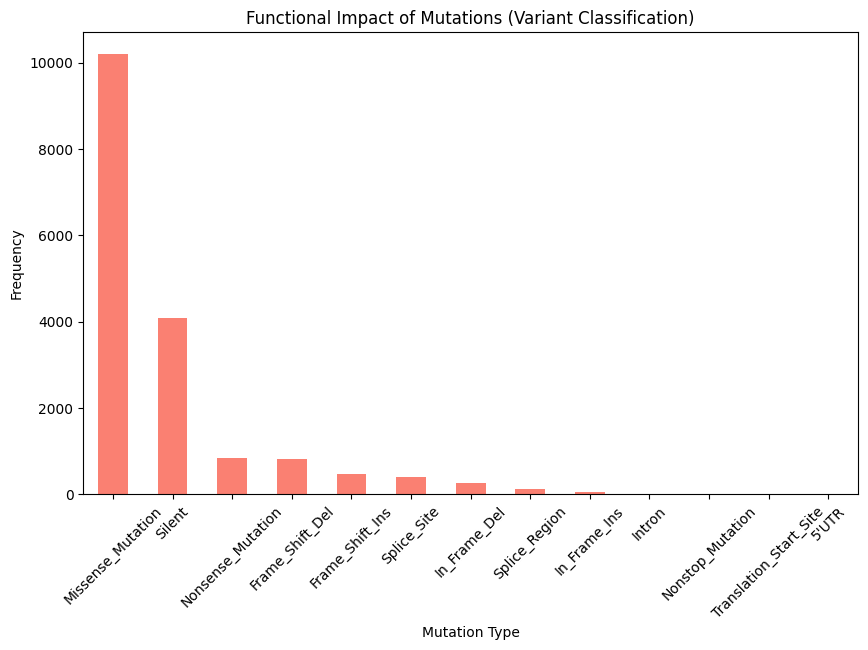

Structural insights for PIK3CA hotspot:
HGVSp_Short
p.H1047R    424
p.E545K     174
p.E542K      99
p.N345K      62
p.H1047L     42
p.E726K      28
p.C420R      19
p.Q546R      12
p.G118D      10
p.E545A       8
Name: count, dtype: int64

Functional mapping saved to 'functional_mutation_mapping.csv'!


In [26]:
# STEP 7: Functional & Structural Mapping
# स्टेप 7: फंक्शनल और स्ट्रक्चरल मैपिंग
# ========================================================

# 1. Functional Mapping: Identifying the biological impact of mutations.
# म्यूटेशन के बायोलॉजिकल प्रभाव की मैपिंग (Variant Classification).
# यह बताता है कि म्यूटेशन किस प्रकार का है (जैसे: Missense, Nonsense, Frame shift).
functional_impact = df_mut['Variant_Classification'].value_counts()

# Visualize the functional impact
plt.figure(figsize=(10, 6))
functional_impact.plot(kind='bar', color='salmon')
plt.title('Functional Impact of Mutations (Variant Classification)')
plt.xlabel('Mutation Type')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# 2. Structural Mapping: Focusing on the PIK3CA hotspot.
# चूँकि PIK3CA आपका हीरो जीन है, हम देखेंगे कि इसके म्यूटेशन कहाँ स्थित हैं।
pik3ca_mutations = df_mut[df_mut['Hugo_Symbol'] == 'PIK3CA']

print("Structural insights for PIK3CA hotspot:")
# म्यूटेशन कहाँ-कहाँ हो रहे हैं, यह देखने के लिए 'Protein_Change' कॉलम का उपयोग।
# Correcting the KeyError: 'Protein_Change' by using a common alternative like 'HGVSp_Short'
print(pik3ca_mutations['HGVSp_Short'].value_counts().head(10))

# 3. Saving the mapping results.
functional_impact.to_csv('functional_mutation_mapping.csv')
print("\nFunctional mapping saved to 'functional_mutation_mapping.csv'!")